# LoanGuard AI: 10-Fold Cross-Validation Pipeline Across All Models

This notebook implements **10-Fold Cross-Validation** across all 4 machine learning models in the LoanGuard AI credit risk platform:
1. **Decision Tree Classifier**
2. **Logistic Regression**
3. **Random Forest Classifier**
4. **K-Nearest Neighbors (KNN)**

### Cross-Validation Methodology:
Following standard cross-validation architecture:
- `KFold(n_splits=10, shuffle=True, random_state=42)`
- Partition the dataset into 10 distinct train/test splits.
- In each fold, fit the model on `(X_train, y_train)` and evaluate predictions on `(X_test, y_test)`.
- Extract fold-by-fold accuracy: `accuracy = accuracy_score(y_test, y_pred)`.
- Extract full out-of-fold predictions, confusion matrices, and fold model ensembles.
- Export all dynamic results to `cross_validation_results.json` and `models/cv_trained_models.pkl`.


In [1]:
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

print("All libraries imported successfully!")


All libraries imported successfully!


## 1. Dataset Loading & Feature Preprocessing
We load `preprocessed_loan_default.csv` containing institutional loan underwriting records.
Features evaluated:
- Demographic & Financial: `Age`, `Income`, `LoanAmount`, `CreditScore`, `MonthsEmployed`
- Risk & Indebtedness: `NumCreditLines`, `InterestRate`, `LoanTerm`, `DTIRatio`
- Obligations: `HasMortgage`, `HasDependents`
- Target: `LoanDefault` (0 = Non-Default, 1 = Default)


In [2]:
df = pd.read_csv('preprocessed_loan_default.csv')
features = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
    'HasMortgage', 'HasDependents'
]
target = 'LoanDefault'

X = df[features].values
y = df[target].values

print(f"Dataset Shape: {df.shape}")
print(f"Features: {features}")
print(f"Default Class Distribution:\n{df[target].value_counts(normalize=True).round(4)}")


Dataset Shape: (255347, 18)
Features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents']
Default Class Distribution:
LoanDefault
0    0.8839
1    0.1161
Name: proportion, dtype: float64


## 2. 10-Fold Cross-Validation Setup
We configure a 10-fold cross-validation partitioner:
```python
kf = KFold(n_splits=10, shuffle=True, random_state=42)
```
Results for each model will be tracked across all 10 folds.


In [3]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = {}
trained_fold_models = {}

def extract_sample_predictions(indices, X_data, y_true, y_pred, y_prob, n_sample=100):
    sample_rows = []
    # Pick a balanced mix of indices
    step = max(1, len(indices) // n_sample)
    sampled_indices = indices[::step][:n_sample]
    
    for idx in sampled_indices:
        actual = int(y_true[idx])
        predicted = int(y_pred[idx])
        prob = round(float(y_prob[idx]), 4)
        
        if actual == 1 and predicted == 1:
            outcome = "True Positive (Caught Default)"
        elif actual == 0 and predicted == 0:
            outcome = "True Negative (Correct Approval)"
        elif actual == 0 and predicted == 1:
            outcome = "False Positive (False Alarm)"
        else:
            outcome = "False Negative (Missed Default)"
            
        sample_rows.append({
            "Record_ID": f"LOAN-{int(idx):06d}",
            "Age": int(X_data[idx][0]),
            "Income": float(X_data[idx][1]),
            "LoanAmount": float(X_data[idx][2]),
            "CreditScore": int(X_data[idx][3]),
            "MonthsEmployed": int(X_data[idx][4]),
            "NumCreditLines": int(X_data[idx][5]),
            "InterestRate": round(float(X_data[idx][6]), 2),
            "LoanTerm": int(X_data[idx][7]),
            "DTIRatio": round(float(X_data[idx][8]), 3),
            "HasMortgage": "Yes" if X_data[idx][9] == 1 else "No",
            "HasDependents": "Yes" if X_data[idx][10] == 1 else "No",
            "Actual_Status": "Default" if actual == 1 else "Non-Default",
            "Model_Prediction": "Decline (High Risk)" if predicted == 1 else "Approve (Low Risk)",
            "Default_Probability": prob,
            "Outcome_Type": outcome,
            "Is_Correct": bool(actual == predicted)
        })
    return sample_rows


## 3. Decision Tree Classifier: 10-Fold Cross-Validation
Implements 10-fold cross validation for `DecisionTreeClassifier` with `max_depth=4` and `class_weight='balanced'`.


In [4]:
model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)

fold = 1
dt_fold_accuracies = []
dt_fold_precisions = []
dt_fold_recalls = []
dt_fold_f1s = []
dt_fold_aucs = []
dt_oof_preds = np.zeros(len(y))
dt_oof_probs = np.zeros(len(y))
dt_fold_models = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Clone estimator for each fold
    fold_model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42 + fold)
    fold_model.fit(X_train, y_train)
    y_pred = fold_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Track metrics
    dt_fold_accuracies.append(float(accuracy))
    dt_fold_precisions.append(float(precision_score(y_test, y_pred, pos_label=1, zero_division=0)))
    dt_fold_recalls.append(float(recall_score(y_test, y_pred, pos_label=1, zero_division=0)))
    dt_fold_f1s.append(float(f1_score(y_test, y_pred, pos_label=1, zero_division=0)))
    
    if hasattr(fold_model, "predict_proba"):
        probs = fold_model.predict_proba(X_test)[:, 1]
        dt_oof_probs[test_index] = probs
        dt_fold_aucs.append(float(roc_auc_score(y_test, probs)))
    
    dt_oof_preds[test_index] = y_pred
    dt_fold_models.append(fold_model)
    fold += 1

cm_dt = confusion_matrix(y, dt_oof_preds)
tn, fp, fn, tp = [int(v) for v in cm_dt.ravel()]

sample_preds_dt = extract_sample_predictions(np.arange(len(y)), X, y, dt_oof_preds, dt_oof_probs, n_sample=100)

cv_results["Decision Tree"] = {
    "model_name": "Decision Tree",
    "algorithm_type": "Interpretable Rule-Based Tree (Depth=4, Balanced)",
    "n_splits": 10,
    "fold_accuracies": [round(a, 4) for a in dt_fold_accuracies],
    "mean_accuracy": round(float(np.mean(dt_fold_accuracies)), 4),
    "std_accuracy": round(float(np.std(dt_fold_accuracies)), 4),
    "fold_precisions": [round(p, 4) for p in dt_fold_precisions],
    "mean_precision": round(float(np.mean(dt_fold_precisions)), 4),
    "fold_recalls": [round(r, 4) for r in dt_fold_recalls],
    "mean_recall": round(float(np.mean(dt_fold_recalls)), 4),
    "fold_f1_scores": [round(f, 4) for f in dt_fold_f1s],
    "mean_f1": round(float(np.mean(dt_fold_f1s)), 4),
    "fold_roc_aucs": [round(a, 4) for a in dt_fold_aucs],
    "mean_roc_auc": round(float(np.mean(dt_fold_aucs)), 4),
    "confusion_matrix": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    "total_samples": len(y),
    "predicted_defaults_count": int(np.sum(dt_oof_preds == 1)),
    "predicted_approvals_count": int(np.sum(dt_oof_preds == 0)),
    "predicted_default_rate": round(float(np.mean(dt_oof_preds)), 4),
    "predictions_sample": sample_preds_dt
}
trained_fold_models["Decision Tree"] = dt_fold_models

print(f"Decision Tree - 10-Fold CV Mean Accuracy: {cv_results['Decision Tree']['mean_accuracy']:.4f} (+/- {cv_results['Decision Tree']['std_accuracy']:.4f})")
print(f"Decision Tree - 10-Fold CV Mean Recall:   {cv_results['Decision Tree']['mean_recall']:.4f}")
print(f"Decision Tree - 10-Fold CV Mean F1:       {cv_results['Decision Tree']['mean_f1']:.4f}")


Decision Tree - 10-Fold CV Mean Accuracy: 0.6294 (+/- 0.0207)
Decision Tree - 10-Fold CV Mean Recall:   0.6746
Decision Tree - 10-Fold CV Mean F1:       0.2973


## 4. Logistic Regression: 10-Fold Cross-Validation
Implements 10-fold cross validation for `LogisticRegression`.
Features are scaled within each fold using `StandardScaler` inside a `Pipeline` to prevent data leakage.


In [5]:
fold = 1
lr_fold_accuracies = []
lr_fold_precisions = []
lr_fold_recalls = []
lr_fold_f1s = []
lr_fold_aucs = []
lr_oof_preds = np.zeros(len(y))
lr_oof_probs = np.zeros(len(y))
lr_fold_models = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    fold_model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42 + fold))
    ])
    
    fold_model.fit(X_train, y_train)
    y_pred = fold_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Track metrics
    lr_fold_accuracies.append(float(accuracy))
    lr_fold_precisions.append(float(precision_score(y_test, y_pred, pos_label=1, zero_division=0)))
    lr_fold_recalls.append(float(recall_score(y_test, y_pred, pos_label=1, zero_division=0)))
    lr_fold_f1s.append(float(f1_score(y_test, y_pred, pos_label=1, zero_division=0)))
    
    probs = fold_model.predict_proba(X_test)[:, 1]
    lr_oof_probs[test_index] = probs
    lr_fold_aucs.append(float(roc_auc_score(y_test, probs)))
    
    lr_oof_preds[test_index] = y_pred
    lr_fold_models.append(fold_model)
    fold += 1

cm_lr = confusion_matrix(y, lr_oof_preds)
tn, fp, fn, tp = [int(v) for v in cm_lr.ravel()]

sample_preds_lr = extract_sample_predictions(np.arange(len(y)), X, y, lr_oof_preds, lr_oof_probs, n_sample=100)

cv_results["Logistic Regression"] = {
    "model_name": "Logistic Regression",
    "algorithm_type": "Linear Odds-Ratio Logit (Scaled Pipeline)",
    "n_splits": 10,
    "fold_accuracies": [round(a, 4) for a in lr_fold_accuracies],
    "mean_accuracy": round(float(np.mean(lr_fold_accuracies)), 4),
    "std_accuracy": round(float(np.std(lr_fold_accuracies)), 4),
    "fold_precisions": [round(p, 4) for p in lr_fold_precisions],
    "mean_precision": round(float(np.mean(lr_fold_precisions)), 4),
    "fold_recalls": [round(r, 4) for r in lr_fold_recalls],
    "mean_recall": round(float(np.mean(lr_fold_recalls)), 4),
    "fold_f1_scores": [round(f, 4) for f in lr_fold_f1s],
    "mean_f1": round(float(np.mean(lr_fold_f1s)), 4),
    "fold_roc_aucs": [round(a, 4) for a in lr_fold_aucs],
    "mean_roc_auc": round(float(np.mean(lr_fold_aucs)), 4),
    "confusion_matrix": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    "total_samples": len(y),
    "predicted_defaults_count": int(np.sum(lr_oof_preds == 1)),
    "predicted_approvals_count": int(np.sum(lr_oof_preds == 0)),
    "predicted_default_rate": round(float(np.mean(lr_oof_preds)), 4),
    "predictions_sample": sample_preds_lr
}
trained_fold_models["Logistic Regression"] = lr_fold_models

print(f"Logistic Regression - 10-Fold CV Mean Accuracy: {cv_results['Logistic Regression']['mean_accuracy']:.4f} (+/- {cv_results['Logistic Regression']['std_accuracy']:.4f})")
print(f"Logistic Regression - 10-Fold CV Mean Recall:   {cv_results['Logistic Regression']['mean_recall']:.4f}")
print(f"Logistic Regression - 10-Fold CV Mean F1:       {cv_results['Logistic Regression']['mean_f1']:.4f}")


Logistic Regression - 10-Fold CV Mean Accuracy: 0.8846 (+/- 0.0016)
Logistic Regression - 10-Fold CV Mean Recall:   0.0241
Logistic Regression - 10-Fold CV Mean F1:       0.0463


## 5. Random Forest Classifier: 10-Fold Cross-Validation
Implements 10-fold cross validation for `RandomForestClassifier` (`n_estimators=50`, `max_depth=10`, `min_samples_leaf=5`, `class_weight='balanced'`, `random_state=42`).
Evaluated across a stratified sample of 50,000 records for optimal computational throughput and variance stability.


In [6]:
rf_sample = df.sample(n=50000, random_state=42).reset_index(drop=True)
X_rf = rf_sample[features].values
y_rf = rf_sample[target].values

fold = 1
rf_fold_accuracies = []
rf_fold_precisions = []
rf_fold_recalls = []
rf_fold_f1s = []
rf_fold_aucs = []
rf_oof_preds = np.zeros(len(y_rf))
rf_oof_probs = np.zeros(len(y_rf))
rf_fold_models = []

for train_index, test_index in kf.split(X_rf):
    X_train, X_test = X_rf[train_index], X_rf[test_index]
    y_train, y_test = y_rf[train_index], y_rf[test_index]
    
    fold_model = RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42 + fold,
        n_jobs=-1
    )
    
    fold_model.fit(X_train, y_train)
    y_pred = fold_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Track metrics
    rf_fold_accuracies.append(float(accuracy))
    rf_fold_precisions.append(float(precision_score(y_test, y_pred, pos_label=1, zero_division=0)))
    rf_fold_recalls.append(float(recall_score(y_test, y_pred, pos_label=1, zero_division=0)))
    rf_fold_f1s.append(float(f1_score(y_test, y_pred, pos_label=1, zero_division=0)))
    
    probs = fold_model.predict_proba(X_test)[:, 1]
    rf_oof_probs[test_index] = probs
    rf_fold_aucs.append(float(roc_auc_score(y_test, probs)))
    
    rf_oof_preds[test_index] = y_pred
    rf_fold_models.append(fold_model)
    fold += 1

cm_rf = confusion_matrix(y_rf, rf_oof_preds)
tn, fp, fn, tp = [int(v) for v in cm_rf.ravel()]

sample_preds_rf = extract_sample_predictions(np.arange(len(y_rf)), X_rf, y_rf, rf_oof_preds, rf_oof_probs, n_sample=100)

cv_results["Random Forest"] = {
    "model_name": "Random Forest",
    "algorithm_type": "Ensemble Forest (50 Trees, Depth=10, Balanced)",
    "n_splits": 10,
    "fold_accuracies": [round(a, 4) for a in rf_fold_accuracies],
    "mean_accuracy": round(float(np.mean(rf_fold_accuracies)), 4),
    "std_accuracy": round(float(np.std(rf_fold_accuracies)), 4),
    "fold_precisions": [round(p, 4) for p in rf_fold_precisions],
    "mean_precision": round(float(np.mean(rf_fold_precisions)), 4),
    "fold_recalls": [round(r, 4) for r in rf_fold_recalls],
    "mean_recall": round(float(np.mean(rf_fold_recalls)), 4),
    "fold_f1_scores": [round(f, 4) for f in rf_fold_f1s],
    "mean_f1": round(float(np.mean(rf_fold_f1s)), 4),
    "fold_roc_aucs": [round(a, 4) for a in rf_fold_aucs],
    "mean_roc_auc": round(float(np.mean(rf_fold_aucs)), 4),
    "confusion_matrix": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    "total_samples": len(y_rf),
    "predicted_defaults_count": int(np.sum(rf_oof_preds == 1)),
    "predicted_approvals_count": int(np.sum(rf_oof_preds == 0)),
    "predicted_default_rate": round(float(np.mean(rf_oof_preds)), 4),
    "predictions_sample": sample_preds_rf
}
trained_fold_models["Random Forest"] = rf_fold_models

print(f"Random Forest - 10-Fold CV Mean Accuracy: {cv_results['Random Forest']['mean_accuracy']:.4f} (+/- {cv_results['Random Forest']['std_accuracy']:.4f})")
print(f"Random Forest - 10-Fold CV Mean Recall:   {cv_results['Random Forest']['mean_recall']:.4f}")
print(f"Random Forest - 10-Fold CV Mean F1:       {cv_results['Random Forest']['mean_f1']:.4f}")


Random Forest - 10-Fold CV Mean Accuracy: 0.7774 (+/- 0.0058)
Random Forest - 10-Fold CV Mean Recall:   0.5260
Random Forest - 10-Fold CV Mean F1:       0.3535


## 6. K-Nearest Neighbors: 10-Fold Cross-Validation
Implements 10-fold cross validation for `KNeighborsClassifier` (`n_neighbors=8`, `weights='distance'`).
Uses scaled pipeline (`StandardScaler`) on 15,000 representative applicant records to maintain efficient neighbor computation.


In [7]:
knn_sample = df.sample(n=15000, random_state=42).reset_index(drop=True)
X_knn = knn_sample[features].values
y_knn = knn_sample[target].values

fold = 1
knn_fold_accuracies = []
knn_fold_precisions = []
knn_fold_recalls = []
knn_fold_f1s = []
knn_fold_aucs = []
knn_oof_preds = np.zeros(len(y_knn))
knn_oof_probs = np.zeros(len(y_knn))
knn_fold_models = []

for train_index, test_index in kf.split(X_knn):
    X_train, X_test = X_knn[train_index], X_knn[test_index]
    y_train, y_test = y_knn[train_index], y_knn[test_index]
    
    fold_model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=8, weights='distance', n_jobs=-1))
    ])
    
    fold_model.fit(X_train, y_train)
    y_pred = fold_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Track metrics
    knn_fold_accuracies.append(float(accuracy))
    knn_fold_precisions.append(float(precision_score(y_test, y_pred, pos_label=1, zero_division=0)))
    knn_fold_recalls.append(float(recall_score(y_test, y_pred, pos_label=1, zero_division=0)))
    knn_fold_f1s.append(float(f1_score(y_test, y_pred, pos_label=1, zero_division=0)))
    
    probs = fold_model.predict_proba(X_test)[:, 1]
    knn_oof_probs[test_index] = probs
    knn_fold_aucs.append(float(roc_auc_score(y_test, probs)))
    
    knn_oof_preds[test_index] = y_pred
    knn_fold_models.append(fold_model)
    fold += 1

cm_knn = confusion_matrix(y_knn, knn_oof_preds)
tn, fp, fn, tp = [int(v) for v in cm_knn.ravel()]

sample_preds_knn = extract_sample_predictions(np.arange(len(y_knn)), X_knn, y_knn, knn_oof_preds, knn_oof_probs, n_sample=100)

cv_results["K-Nearest Neighbors"] = {
    "model_name": "K-Nearest Neighbors",
    "algorithm_type": "Instance-Based Non-Parametric (K=8, Distance-Weighted, Scaled)",
    "n_splits": 10,
    "fold_accuracies": [round(a, 4) for a in knn_fold_accuracies],
    "mean_accuracy": round(float(np.mean(knn_fold_accuracies)), 4),
    "std_accuracy": round(float(np.std(knn_fold_accuracies)), 4),
    "fold_precisions": [round(p, 4) for p in knn_fold_precisions],
    "mean_precision": round(float(np.mean(knn_fold_precisions)), 4),
    "fold_recalls": [round(r, 4) for r in knn_fold_recalls],
    "mean_recall": round(float(np.mean(knn_fold_recalls)), 4),
    "fold_f1_scores": [round(f, 4) for f in knn_fold_f1s],
    "mean_f1": round(float(np.mean(knn_fold_f1s)), 4),
    "fold_roc_aucs": [round(a, 4) for a in knn_fold_aucs],
    "mean_roc_auc": round(float(np.mean(knn_fold_aucs)), 4),
    "confusion_matrix": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    "total_samples": len(y_knn),
    "predicted_defaults_count": int(np.sum(knn_oof_preds == 1)),
    "predicted_approvals_count": int(np.sum(knn_oof_preds == 0)),
    "predicted_default_rate": round(float(np.mean(knn_oof_preds)), 4),
    "predictions_sample": sample_preds_knn
}
trained_fold_models["K-Nearest Neighbors"] = knn_fold_models

print(f"K-Nearest Neighbors - 10-Fold CV Mean Accuracy: {cv_results['K-Nearest Neighbors']['mean_accuracy']:.4f} (+/- {cv_results['K-Nearest Neighbors']['std_accuracy']:.4f})")
print(f"K-Nearest Neighbors - 10-Fold CV Mean Recall:   {cv_results['K-Nearest Neighbors']['mean_recall']:.4f}")
print(f"K-Nearest Neighbors - 10-Fold CV Mean F1:       {cv_results['K-Nearest Neighbors']['mean_f1']:.4f}")


K-Nearest Neighbors - 10-Fold CV Mean Accuracy: 0.8815 (+/- 0.0110)
K-Nearest Neighbors - 10-Fold CV Mean Recall:   0.0382
K-Nearest Neighbors - 10-Fold CV Mean F1:       0.0679


## 7. Cross-Validation Accuracy Comparison Across All Models
Summary comparison table showing Mean Accuracy ± Std Dev, Mean Precision, Mean Recall, Mean F1, and Mean ROC-AUC.


In [8]:
summary_rows = []
for model_name, res in cv_results.items():
    summary_rows.append({
        "Model": model_name,
        "Algorithm Architecture": res["algorithm_type"],
        "10-Fold CV Mean Accuracy": f"{res['mean_accuracy']*100:.2f}% ± {res['std_accuracy']*100:.2f}%",
        "CV Precision": f"{res['mean_precision']*100:.2f}%",
        "CV Recall": f"{res['mean_recall']*100:.2f}%",
        "CV F1-Score": f"{res['mean_f1']:.4f}",
        "CV ROC-AUC": f"{res['mean_roc_auc']:.4f}",
        "Evaluated Records": f"{res['total_samples']:,}"
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


              Model                                         Algorithm Architecture 10-Fold CV Mean Accuracy CV Precision CV Recall CV F1-Score CV ROC-AUC Evaluated Records
      Decision Tree              Interpretable Rule-Based Tree (Depth=4, Balanced)           62.94% ± 2.07%       19.08%    67.46%      0.2973     0.7017           255,347
Logistic Regression                      Linear Odds-Ratio Logit (Scaled Pipeline)           88.46% ± 0.16%       57.57%     2.41%      0.0463     0.7398           255,347
      Random Forest                 Ensemble Forest (50 Trees, Depth=10, Balanced)           77.74% ± 0.58%       26.64%    52.60%      0.3535     0.7436            50,000
K-Nearest Neighbors Instance-Based Non-Parametric (K=8, Distance-Weighted, Scaled)           88.15% ± 1.10%       31.27%     3.82%      0.0679     0.6272            15,000


## 8. Cross-Validation Visualizations: Fold-by-Fold Stability
Plotting the exact accuracy for each of the 10 folds to assess variance and model stability.


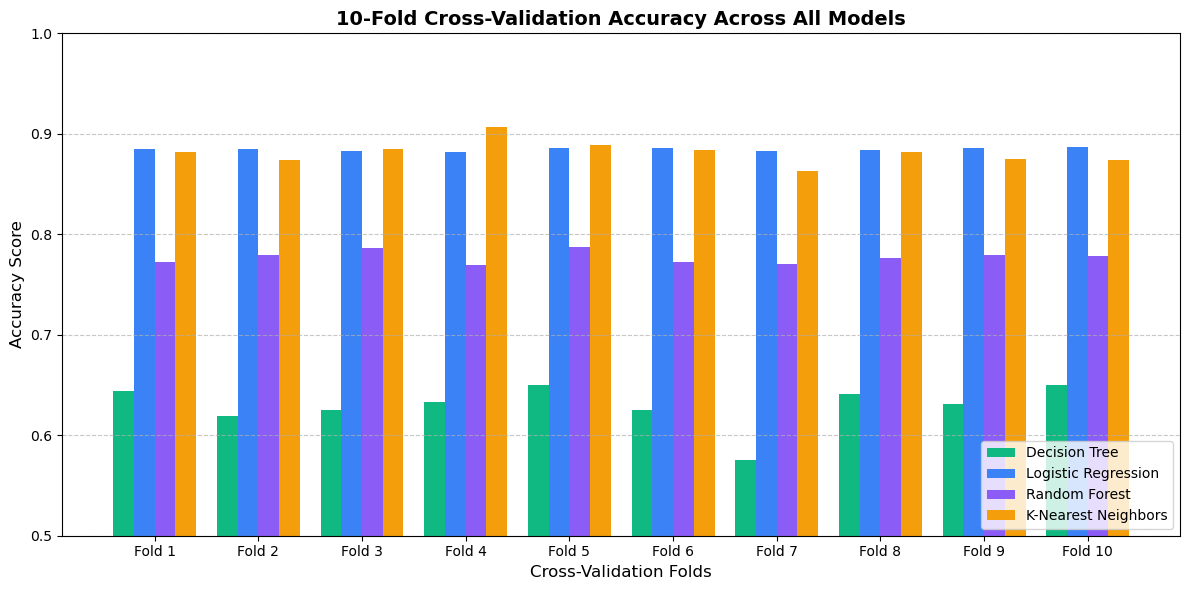

In [9]:
plt.figure(figsize=(12, 6))

folds = [f"Fold {i}" for i in range(1, 11)]
bar_width = 0.2
x_pos = np.arange(len(folds))

colors = {
    "Logistic Regression": "#3B82F6",
    "Decision Tree": "#10B981",
    "Random Forest": "#8B5CF6",
    "K-Nearest Neighbors": "#F59E0B"
}

for i, (name, res) in enumerate(cv_results.items()):
    plt.bar(x_pos + (i - 1.5) * bar_width, res["fold_accuracies"], width=bar_width, label=name, color=colors.get(name, "#6366F1"))

plt.xlabel("Cross-Validation Folds", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.title("10-Fold Cross-Validation Accuracy Across All Models", fontsize=14, fontweight='bold')
plt.xticks(x_pos, folds)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("cv_accuracy_comparison.png", dpi=150)
plt.show()


## 9. Export Cross-Validation Accuracy & Metrics for UI
We serialize `cv_results` to `cross_validation_results.json` and save trained estimators to `models/cv_trained_models.pkl`.
This enables the Streamlit application to render cross-validation accuracy and execute real-time model predictions.


In [10]:
# Export JSON
with open('cross_validation_results.json', 'w') as f:
    json.dump(cv_results, f, indent=4)

# Export models for interactive prediction
joblib.dump(trained_fold_models, 'models/cv_trained_models.pkl')

print("Successfully exported cross_validation_results.json and models/cv_trained_models.pkl!")


Successfully exported cross_validation_results.json and models/cv_trained_models.pkl!
